In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT / "src"))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from pangya_physics.club import CLUBS

In [3]:
dataset_path = PROJECT_ROOT / "data" / "processed" / "club_dataset_analysis.csv"

df_valid = pd.read_csv(dataset_path)

df_valid.head()

,club,club_type,target_distance,power_percent,power_range,final_distance,error,abs_error,iterations,found,reachable
0,1W,wood,50,0.310937,71.515625,49.729930,0.270070,0.270070,8,True,True
1,1W,wood,60,0.343750,79.062500,60.493727,-0.493727,0.493727,6,True,True
2,1W,wood,70,0.371875,85.531250,69.761391,0.238609,0.238609,7,True,True
3,1W,wood,80,0.400000,92.000000,79.559358,0.440642,0.440642,2,True,True
4,1W,wood,90,0.428125,98.468750,89.857723,0.142277,0.142277,7,True,True


In [4]:
df_valid["power_percent_display"] = df_valid["power_percent"] * 100
df_valid["efficiency"] = df_valid["target_distance"] / df_valid["power_percent_display"]

df_valid.head()

,club,club_type,target_distance,power_percent,power_range,final_distance,error,abs_error,iterations,found,reachable,power_percent_display,efficiency
0,1W,wood,50,0.310937,71.515625,49.729930,0.270070,0.270070,8,True,True,31.09375,1.608040
1,1W,wood,60,0.343750,79.062500,60.493727,-0.493727,0.493727,6,True,True,34.37500,1.745455
2,1W,wood,70,0.371875,85.531250,69.761391,0.238609,0.238609,7,True,True,37.18750,1.882353
3,1W,wood,80,0.400000,92.000000,79.559358,0.440642,0.440642,2,True,True,40.00000,2.000000
4,1W,wood,90,0.428125,98.468750,89.857723,0.142277,0.142277,7,True,True,42.81250,2.102190


In [5]:
club_order = list(CLUBS.keys())

club_order

['1W', '2W', '3W', '2I', '3I', '4I', '5I', '6I', '7I', '8I', '9I', 'PW', 'SW']

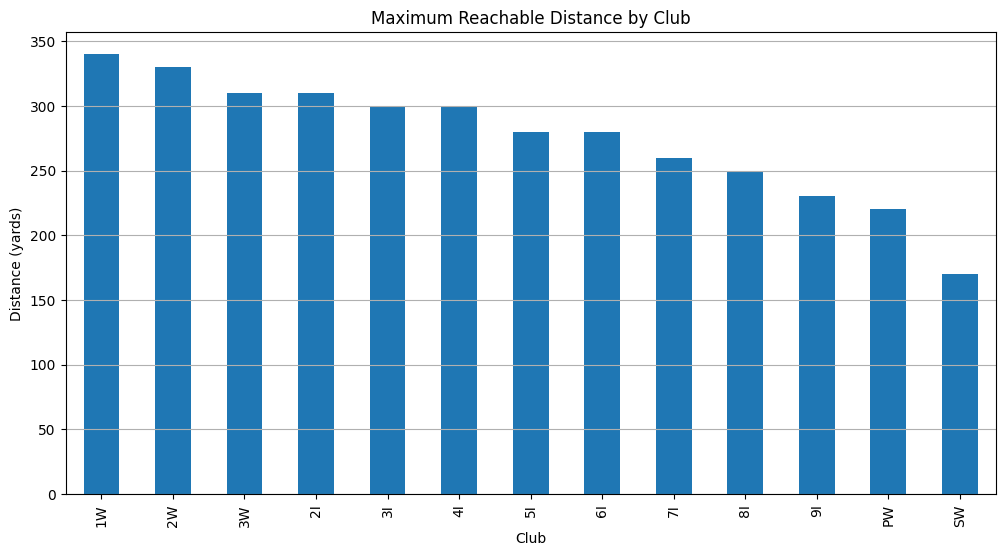

In [6]:
club_ranges = (
    df_valid.groupby("club")["target_distance"]
    .max()
    .reindex(club_order)
    .dropna()
)

plt.figure(figsize=(12, 6))

club_ranges.plot(kind="bar")

plt.title("Maximum Reachable Distance by Club")
plt.xlabel("Club")
plt.ylabel("Distance (yards)")
plt.grid(axis="y")

plt.show()

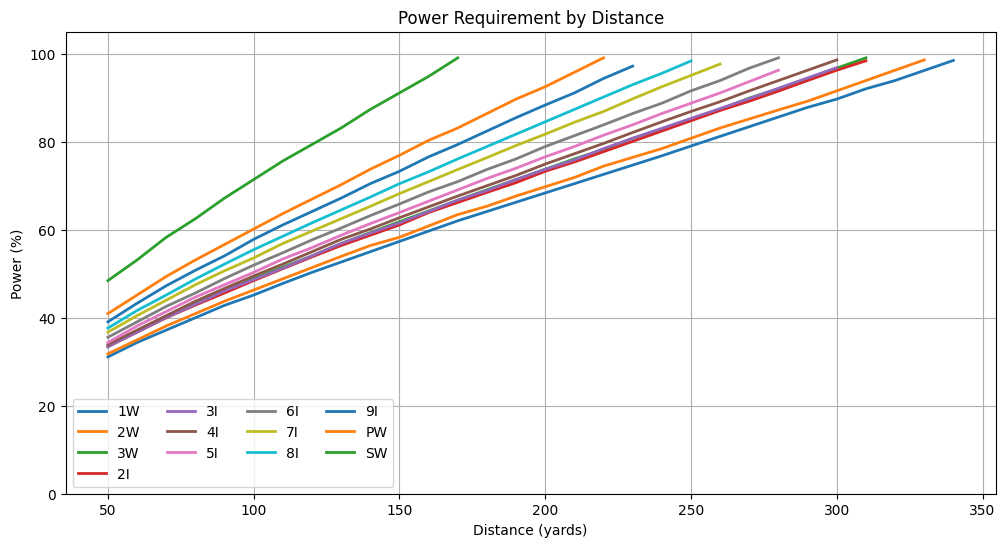

In [7]:
plt.figure(figsize=(12, 6))

for club in club_order:
    club_df = df_valid[df_valid["club"] == club]

    if club_df.empty:
        continue

    plt.plot(
        club_df["target_distance"],
        club_df["power_percent_display"],
        label=club,
        linewidth=2,
    )

plt.title("Power Requirement by Distance")
plt.xlabel("Distance (yards)")
plt.ylabel("Power (%)")
plt.ylim(0, 105)
plt.grid(True)
plt.legend(ncol=4)

plt.show()

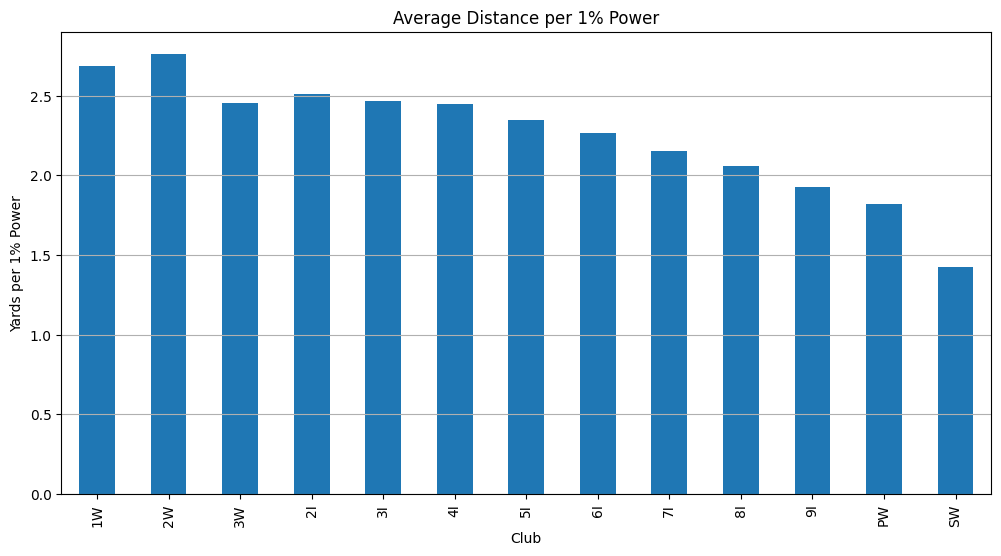

In [8]:
efficiency = (
    df_valid.groupby("club")["efficiency"]
    .mean()
    .reindex(club_order)
    .dropna()
)

plt.figure(figsize=(12, 6))

efficiency.plot(kind="bar")

plt.title("Average Distance per 1% Power")
plt.xlabel("Club")
plt.ylabel("Yards per 1% Power")
plt.grid(axis="y")

plt.show()

In [9]:
club_physics = pd.DataFrame([
    {
        "club": name,
        "club_type": club.club_type.value,
        "rotation_spin": club.rotation_spin,
        "rotation_curve": club.rotation_curve,
        "power_factor": club.power_factor,
        "degree": club.degree,
        "power_base": club.power_base,
    }
    for name, club in CLUBS.items()
])

club_physics

,club,club_type,rotation_spin,rotation_curve,power_factor,degree,power_base
0,1W,wood,0.55,1.61,236.0,10.0,230.0
1,2W,wood,0.50,1.41,204.0,13.0,210.0
2,3W,wood,0.45,1.26,176.0,16.0,190.0
3,2I,iron,0.45,1.07,161.0,20.0,180.0
4,3I,iron,0.45,0.95,149.0,24.0,170.0
5,4I,iron,0.45,0.83,139.0,28.0,160.0
6,5I,iron,0.45,0.73,131.0,32.0,150.0
7,6I,iron,0.41,0.67,124.0,36.0,140.0
8,7I,iron,0.36,0.61,118.0,40.0,130.0
9,8I,iron,0.30,0.57,114.0,44.0,120.0


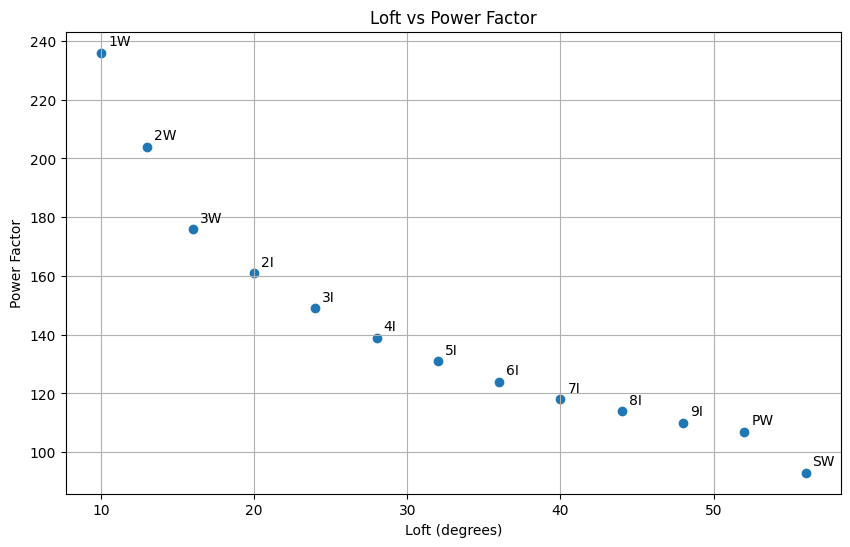

In [10]:
plt.figure(figsize=(10, 6))

plt.scatter(
    club_physics["degree"],
    club_physics["power_factor"],
)

for _, row in club_physics.iterrows():
    plt.annotate(
        row["club"],
        (row["degree"], row["power_factor"]),
        textcoords="offset points",
        xytext=(5, 5),
    )

plt.title("Loft vs Power Factor")
plt.xlabel("Loft (degrees)")
plt.ylabel("Power Factor")
plt.grid(True)

plt.show()

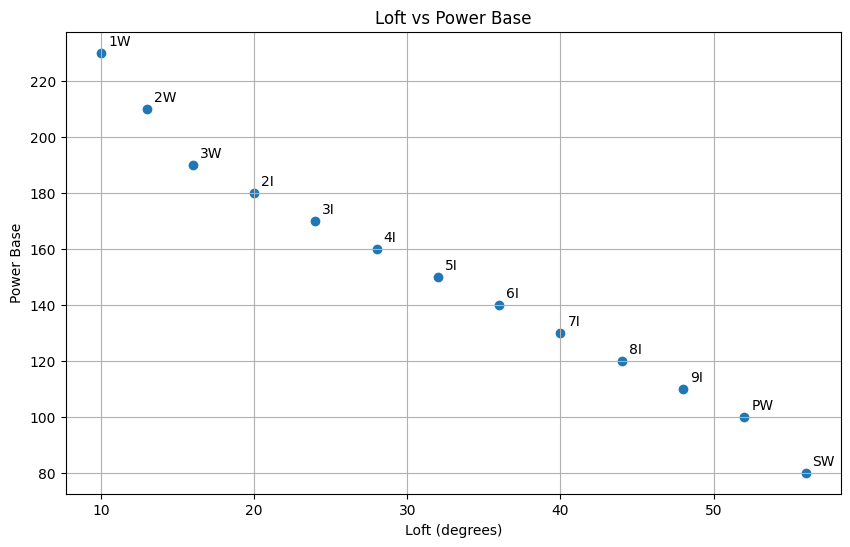

In [11]:
plt.figure(figsize=(10, 6))

plt.scatter(
    club_physics["degree"],
    club_physics["power_base"],
)

for _, row in club_physics.iterrows():
    plt.annotate(
        row["club"],
        (row["degree"], row["power_base"]),
        textcoords="offset points",
        xytext=(5, 5),
    )

plt.title("Loft vs Power Base")
plt.xlabel("Loft (degrees)")
plt.ylabel("Power Base")
plt.grid(True)

plt.show()

In [12]:
error_summary = (
    df_valid.groupby("club")
    .agg(
        avg_abs_error=("abs_error", "mean"),
        max_abs_error=("abs_error", "max"),
        avg_iterations=("iterations", "mean"),
        max_distance=("target_distance", "max"),
    )
    .reindex(club_order)
    .dropna()
)

error_summary

,avg_abs_error,max_abs_error,avg_iterations,max_distance
club,,,,
1W,0.357970,0.497257,7.782609,340
2W,0.315759,0.489845,7.714286,330
3W,0.287092,0.484562,7.958333,310
2I,0.269870,0.483223,8.333333,310
3I,0.284440,0.498410,9.041667,300
4I,0.332069,0.496239,7.807692,300
5I,0.253131,0.493685,7.666667,280
6I,0.245728,0.496898,8.260870,280
7I,0.287521,0.497197,8.045455,260


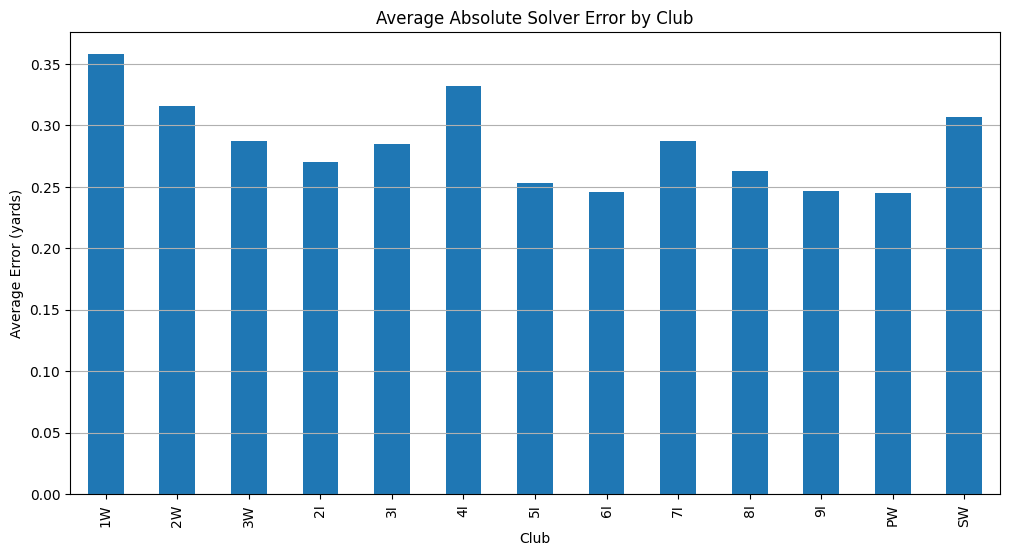

In [13]:
plt.figure(figsize=(12, 6))

error_summary["avg_abs_error"].plot(kind="bar")

plt.title("Average Absolute Solver Error by Club")
plt.xlabel("Club")
plt.ylabel("Average Error (yards)")
plt.grid(axis="y")

plt.show()

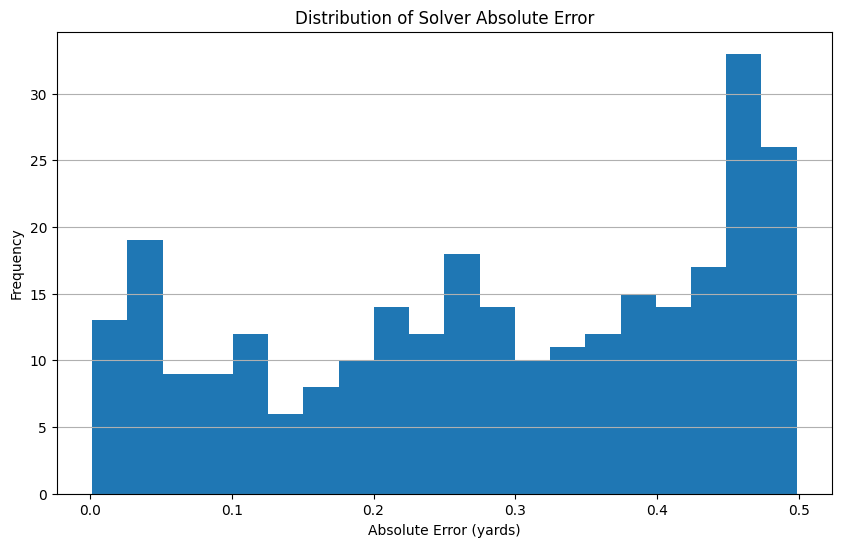

In [14]:
plt.figure(figsize=(10, 6))

plt.hist(
    df_valid["abs_error"],
    bins=20,
)

plt.title("Distribution of Solver Absolute Error")
plt.xlabel("Absolute Error (yards)")
plt.ylabel("Frequency")
plt.grid(axis="y")

plt.show()

In [15]:
club_summary = (
    club_physics
    .merge(
        error_summary.reset_index(),
        on="club",
        how="left",
    )
    .sort_values("power_factor", ascending=False)
)

club_summary

,club,club_type,rotation_spin,rotation_curve,power_factor,degree,power_base,avg_abs_error,max_abs_error,avg_iterations,max_distance
0,1W,wood,0.55,1.61,236.0,10.0,230.0,0.357970,0.497257,7.782609,340
1,2W,wood,0.50,1.41,204.0,13.0,210.0,0.315759,0.489845,7.714286,330
2,3W,wood,0.45,1.26,176.0,16.0,190.0,0.287092,0.484562,7.958333,310
3,2I,iron,0.45,1.07,161.0,20.0,180.0,0.269870,0.483223,8.333333,310
4,3I,iron,0.45,0.95,149.0,24.0,170.0,0.284440,0.498410,9.041667,300
5,4I,iron,0.45,0.83,139.0,28.0,160.0,0.332069,0.496239,7.807692,300
6,5I,iron,0.45,0.73,131.0,32.0,150.0,0.253131,0.493685,7.666667,280
7,6I,iron,0.41,0.67,124.0,36.0,140.0,0.245728,0.496898,8.260870,280
8,7I,iron,0.36,0.61,118.0,40.0,130.0,0.287521,0.497197,8.045455,260
9,8I,iron,0.30,0.57,114.0,44.0,120.0,0.263130,0.479301,8.428571,250


In [16]:
images_dir = PROJECT_ROOT / "docs" / "images"
images_dir.mkdir(parents=True, exist_ok=True)

images_dir

WindowsPath('c:/Users/felip/OneDrive/Documentos/Nova pasta/pangya-shot-physics/docs/images')

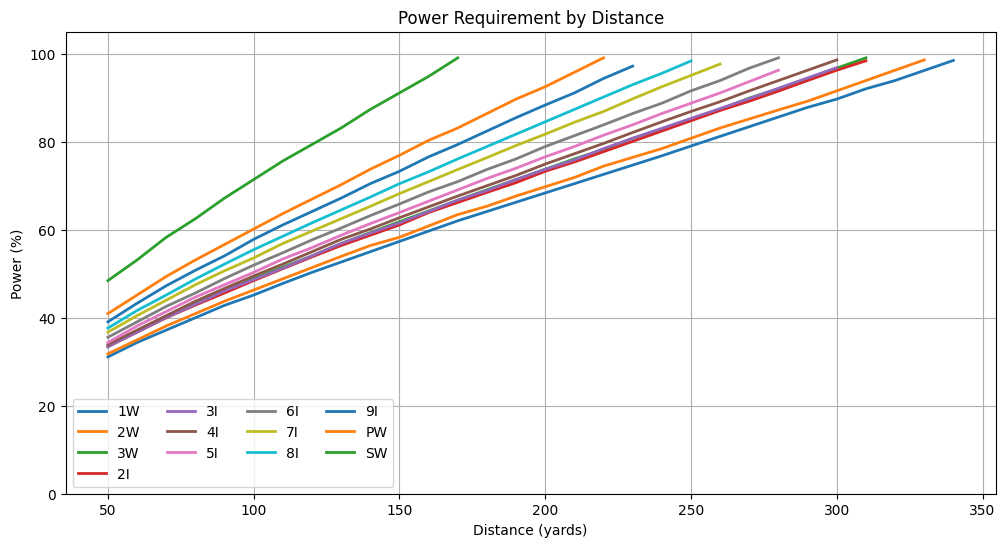

In [17]:
fig = plt.figure(figsize=(12, 6))

for club in club_order:
    club_df = df_valid[df_valid["club"] == club]

    if club_df.empty:
        continue

    plt.plot(
        club_df["target_distance"],
        club_df["power_percent_display"],
        label=club,
        linewidth=2,
    )

plt.title("Power Requirement by Distance")
plt.xlabel("Distance (yards)")
plt.ylabel("Power (%)")
plt.ylim(0, 105)
plt.grid(True)
plt.legend(ncol=4)

plt.savefig(
    images_dir / "power_requirement_by_distance.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

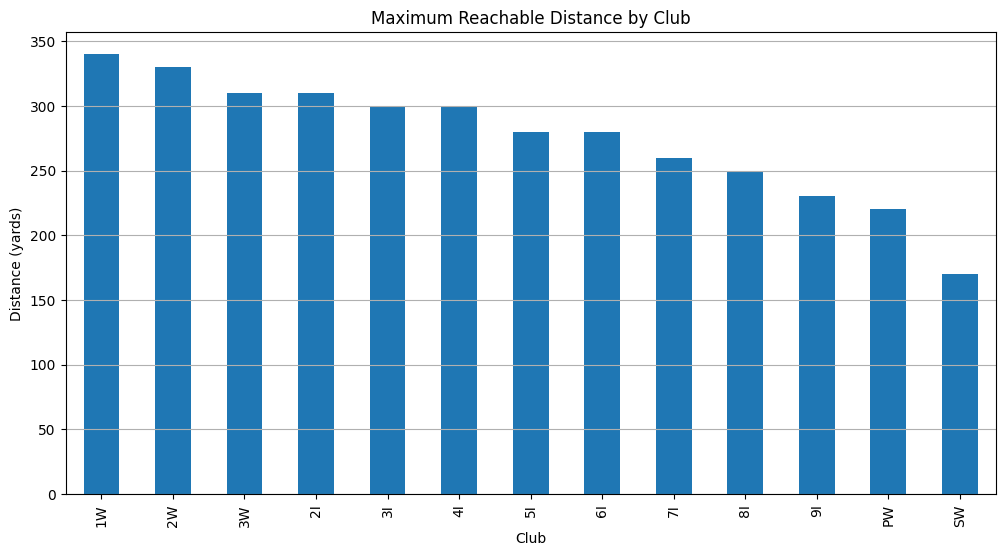

In [18]:
fig = plt.figure(figsize=(12, 6))

club_ranges.plot(kind="bar")

plt.title("Maximum Reachable Distance by Club")
plt.xlabel("Club")
plt.ylabel("Distance (yards)")
plt.grid(axis="y")

plt.savefig(
    images_dir / "maximum_reachable_distance_by_club.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

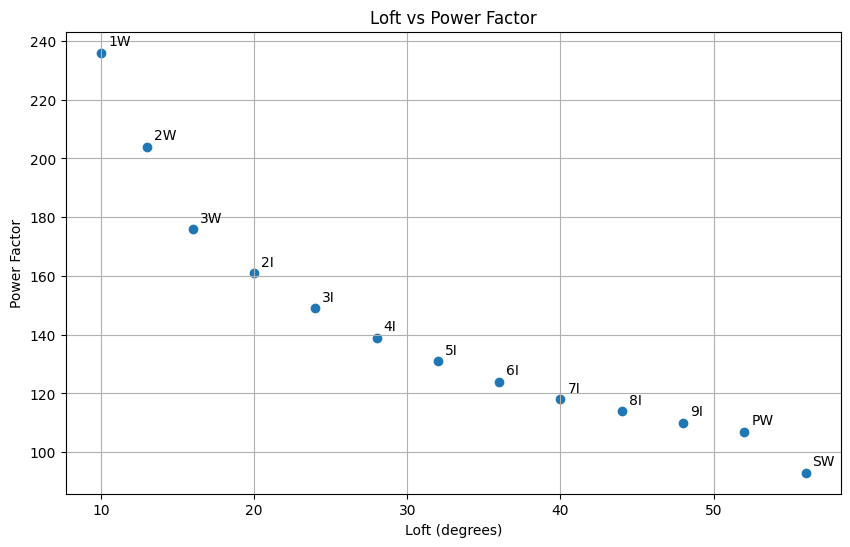

In [19]:
fig = plt.figure(figsize=(10, 6))

plt.scatter(
    club_physics["degree"],
    club_physics["power_factor"],
)

for _, row in club_physics.iterrows():
    plt.annotate(
        row["club"],
        (row["degree"], row["power_factor"]),
        textcoords="offset points",
        xytext=(5, 5),
    )

plt.title("Loft vs Power Factor")
plt.xlabel("Loft (degrees)")
plt.ylabel("Power Factor")
plt.grid(True)

plt.savefig(
    images_dir / "loft_vs_power_factor.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [20]:
club_summary.to_csv(
    PROJECT_ROOT / "data" / "processed" / "club_visualization_summary.csv",
    index=False,
)